In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("D:/prog/Data_Analyst_Pet_Projects/E-Commerce/data.csv", encoding="ISO-8859-1")


In [3]:
df.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,12/1/2010 8:26,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,12/1/2010 8:26,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,12/1/2010 8:28,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,12/1/2010 8:28,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,12/1/2010 8:34,1.69,13047.0,United Kingdom


In [4]:
df.info

<bound method DataFrame.info of        InvoiceNo StockCode                          Description  Quantity  \
0         536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1         536365     71053                  WHITE METAL LANTERN         6   
2         536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3         536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4         536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   
...          ...       ...                                  ...       ...   
541904    581587     22613          PACK OF 20 SPACEBOY NAPKINS        12   
541905    581587     22899         CHILDREN'S APRON DOLLY GIRL          6   
541906    581587     23254        CHILDRENS CUTLERY DOLLY GIRL          4   
541907    581587     23255      CHILDRENS CUTLERY CIRCUS PARADE         4   
541908    581587     22138        BAKING SET 9 PIECE RETROSPOT          3   

            InvoiceDate  UnitPrice  Custome

In [5]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


# Analysis of Columns Based on Descriptive Statistics

- `Column 'Quantity'`: Requires filtering of anomalous values (`Quantity < 0` - returns). Check for duplicate rows with the same `InvoiceNo` and `CustomerID` (possible errors).
  
- `Column 'UnitPrice'`: Remove rows with `UnitPrice < 0` (likely errors). Split prices into quantiles and analyze which products are too expensive.

- `Column 'CustomerID'`: Check rows without `CustomerID` (likely anonymous purchases). Find out how customers are distributed by the number of orders.

## Conclusions

  1. Clean the data — remove negative values in `Quantity` and `UnitPrice`.
  2. Analyze returns (`Quantity < 0`).
  3. Handle missing `CustomerID`.
  4. Build graphs to analyze the distribution of `Quantity` and `UnitPrice`.

In [6]:
df.dtypes

InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object

# Analysis of Column Types

  - `Column 'InvoiceNo'`: Invoice number - the user's order number, type 'object', which needs to be replaced with 'int64', as the column values are integers. Duplicates may exist.
    
  - `Column 'StockCode'`: Stock code, type 'object'. No type change is required. Further checks for duplicates will be performed.
     
  - `Column 'Description'`: Product description, type 'object' is correct.

  - `Column 'Quantity'`: Quantity of a specific product, type 'int64' is correct.

  - `Column 'InvoiceDate'`: Order date, type 'object' is incorrect, it needs to be replaced with 'datetime'..

  - `Column 'UnitPrice'`: Price per unit of the product, type 'float64' is correct.

  - `Column 'CustomerID'`: Unique customer identifier, type 'float64', which is better replaced with 'int64'.

  - `Column 'Country'`: Country of the order, type 'object' is correct.
    

In [7]:
df[['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']].isna().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [8]:
df['InvoiceNo'] = pd.to_numeric(df['InvoiceNo'], errors='coerce').astype('Int64')

In [9]:
df[df['InvoiceNo'].isna()]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,<NA>,D,Discount,-1,12/1/2010 9:41,27.50,14527.0,United Kingdom
154,<NA>,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,12/1/2010 9:49,4.65,15311.0,United Kingdom
235,<NA>,22556,PLASTERS IN TIN CIRCUS PARADE,-12,12/1/2010 10:24,1.65,17548.0,United Kingdom
236,<NA>,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom
237,<NA>,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom
...,...,...,...,...,...,...,...,...
540449,<NA>,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,12/9/2011 9:57,0.83,14397.0,United Kingdom
541541,<NA>,M,Manual,-1,12/9/2011 10:28,224.69,15498.0,United Kingdom
541715,<NA>,21258,VICTORIAN SEWING BOX LARGE,-5,12/9/2011 11:57,10.95,15311.0,United Kingdom
541716,<NA>,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,12/9/2011 11:58,1.25,17315.0,United Kingdom


In [10]:
df[df['StockCode'].isin(df[df['InvoiceNo'].isna()]['StockCode'].unique())] # understand which products are most frequently returned

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France


In [11]:
returns_df = df[df['Quantity'] < 0] # extract returns into a separate dataframe (for analysis)

In [12]:
top_returns = returns_df.groupby('StockCode').agg({'Quantity': 'sum'}).reset_index() # aggregation by StockCode to calculate the number of returns

In [13]:
top_returns_sorted = top_returns.sort_values(by='Quantity', ascending=False) # sort by number of returns 

In [14]:
top_returns_sorted.head(10)

,StockCode,Quantity
2273,84964B,-1
2043,84006,-1
1783,35598D,-1
445,21594,-1
1528,23180,-1
620,21910,-1
2353,85065,-1
1513,23164,-1
1501,23150,-1
1839,37444C,-1


In [15]:
df['IsReturn'] = df['InvoiceNo'].isna()

In [16]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce')

In [17]:
df['CustomerID'] = df['CustomerID'].astype(str)

In [18]:
df.loc[:, 'CustomerID'] = df['CustomerID'].fillna('Guest')

In [19]:
df.loc[df['CustomerID'] == 'nan', 'CustomerID'] = 'Guest'

In [20]:
df[df['UnitPrice'] < 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,IsReturn
299983,<NA>,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,Guest,United Kingdom,True
299984,<NA>,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,Guest,United Kingdom,True


In [21]:
df = df[df['UnitPrice'] >= 0]

In [22]:
df['Description'].isna().sum()

1454

In [23]:
df.loc[:, 'Description'] = df['Description'].fillna('Unknown')

In [24]:
df['Description'].isna().sum()

0

In [25]:
df.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,IsReturn
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,False
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,False
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom,False
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom,False
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom,False
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom,False
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom,False


In [26]:
df['InvoiceDate'].isna().sum()

0

In [27]:
df['InvoiceNo'].isna().sum()

9289

In [28]:
df.isna().sum()

InvoiceNo      9289
StockCode         0
Description       0
Quantity          0
InvoiceDate       0
UnitPrice         0
CustomerID        0
Country           0
IsReturn          0
dtype: int64

In [29]:
df[df['Quantity'] < 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,IsReturn
141,<NA>,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom,True
154,<NA>,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom,True
235,<NA>,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom,True
236,<NA>,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom,True
237,<NA>,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom,True
...,...,...,...,...,...,...,...,...,...
540449,<NA>,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,2011-12-09 09:57:00,0.83,14397.0,United Kingdom,True
541541,<NA>,M,Manual,-1,2011-12-09 10:28:00,224.69,15498.0,United Kingdom,True
541715,<NA>,21258,VICTORIAN SEWING BOX LARGE,-5,2011-12-09 11:57:00,10.95,15311.0,United Kingdom,True
541716,<NA>,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09 11:58:00,1.25,17315.0,United Kingdom,True


# Conclusions

  1. Handling missing values:
     - Missing values in columns were handled using the `fillna()` method. For the `Description` column, missing values were replaced with `'Unknown'`.
     - For the `CustomerID` column, missing values have been replaced with the string `'Guest'`.
     - In the InvoiceNo column, missing or invalid values were cast to `Int64` using `pd.to_numeric()` and then treated as blanks (`NaN`) if they could not be converted to a numeric value.
       
  2. Data type conversion:
     - The `InvoiceNo` column was converted to a numeric data type (`Int64`) using `pd.to_numeric()`, where invalid values were replaced with NaN.
     - The `InvoiceDate` column has been converted to type `datetime` to work correctly with dates.
     - The `CustomerID` column has been converted to a string type to avoid errors when handling gaps.
       
  3. Filtering and analyzing returns:
     - A new `DataFrame returns_df` is created containing only those rows where `Quantity < 0`, which corresponds to product returns.
     - To analyze returns, the `StockCode` column was aggregated to calculate the number of returns for each product. The results were sorted by descending number of returns.
     - The products that were most frequently returned (by the `StockCode` column) were found.
  4. Working with products with negative price:

     - An analysis was performed of items with a negative price (`UnitPrice < 0`), which are likely to be erroneous entries or returns.
     - These rows were removed from the main dataset by filtering `df['UnitPrice'] >= 0`.
  5. Check for missing values:
     - After all manipulations with the data, a final check for missing values in the columns was performed. There were no gaps left in any of the columns, which is confirmed by the output of `df.isna().sum()`, where all values are 0.

## Results
- All missing values were processed.
- Incorrect and unnecessary data has been removed or corrected.
- A returns analysis was performed and the most frequently returned products were identified.
- The data was converted to the required types for further analysis.

# Analysis plan

1. General sales characteristics:
    - What products are sold most frequently (by quantity)?
    - Which products have the highest revenue (by total value)?
    - How are sales distributed across countries?

2. Returns analysis:
    - What products were most frequently returned?
    - Is there a relationship between the number of returns and the price of a product?
    - Which countries or customers make the most returns?
    
3. Customers and purchasing behavior:
    - How many unique customers made purchases?
    - Which customers (by ID) buy the most?

In [73]:
invalid_descriptions = ["?", "damaged", "wrongly marked carton 22804", 'Unknown']
df = df[~df["Description"].isin(invalid_descriptions)]

In [31]:
top_selling_products = df.groupby('StockCode').agg({'Quantity': 'sum'}).reset_index() # group by 'StockCode' and sum 'Quantity' to calculate sales

In [69]:
top_selling_products_sorted= top_selling_products_sorted.iloc[:10][::-1]

In [64]:
top_selling_products = top_selling_products.merge(df[['StockCode', 'Description']].drop_duplicates(), on='StockCode', how='left') # add product description from source DataFrame

In [65]:
top_selling_products_sorted = top_selling_products.sort_values(by='Quantity', ascending=False)

In [75]:
top_selling_products_sorted.head(10)

,StockCode,Quantity,Description_x,Description_y
8740,85123A,35086,CREAM HANGING HEART T-LIGHT HOLDER,WHITE HANGING HEART T-LIGHT HOLDER
8739,85123A,35086,WHITE HANGING HEART T-LIGHT HOLDER,CREAM HANGING HEART T-LIGHT HOLDER
1263,21212,36039,PACK OF 72 RETROSPOT CAKE CASES,PACK OF 72 RETROSPOT CAKE CASES
8178,84879,36381,ASSORTED COLOUR BIRD ORNAMENT,ASSORTED COLOUR BIRD ORNAMENT
8688,85099B,47363,JUMBO BAG RED RETROSPOT,JUMBO BAG RED RETROSPOT
7372,84077,53847,WORLD WAR 2 GLIDERS ASSTD DESIGNS,WORLD WAR 2 GLIDERS ASSTD DESIGNS
2930,22197,56450,SMALL POPCORN HOLDER,SMALL POPCORN HOLDER
2931,22197,56450,SMALL POPCORN HOLDER,POPCORN HOLDER
2932,22197,56450,POPCORN HOLDER,SMALL POPCORN HOLDER
2933,22197,56450,POPCORN HOLDER,POPCORN HOLDER


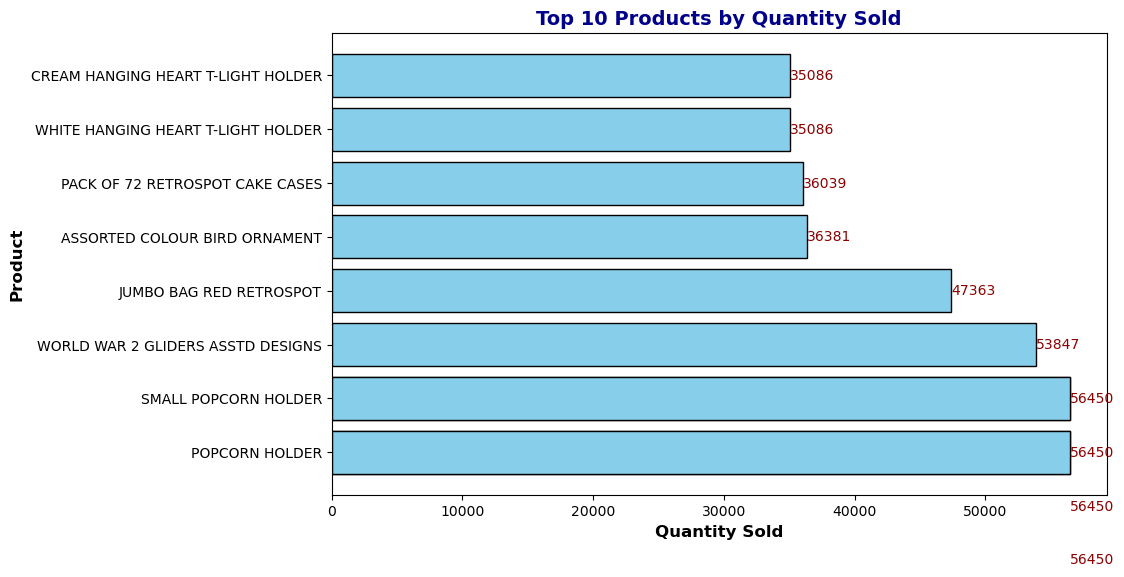

In [77]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.barh(top_selling_products_sorted["Description_x"], top_selling_products_sorted["Quantity"], color="skyblue", edgecolor="black")

for index, value in enumerate(top_selling_products_sorted["Quantity"]):
    plt.text(value, index, str(value), va="center", ha="left", fontsize=10, color="darkred")

plt.xlabel("Quantity Sold", fontsize=12, fontweight="bold")
plt.ylabel("Product", fontsize=12, fontweight="bold")
plt.title("Top 10 Products by Quantity Sold", fontsize=14, fontweight="bold", color="darkblue")
plt.gca().invert_yaxis()
plt.show()


In [ ]:
df['Revenue'] = df['Quantity'] * df['UnitPrice']
top_products_revenue = df.groupby('Description').agg({'Revenue':'sum'}).reset_index()
top_products_revenue_sorted = top_products_revenue.sort_values(by='Revenue', ascending = False)

In [37]:
top_products_revenue_sorted.head(10)

,Description,Revenue
1097,DOTCOM POSTAGE,206245.48
2914,REGENCY CAKESTAND 3 TIER,164762.19
3918,WHITE HANGING HEART T-LIGHT HOLDER,99668.47
2470,PARTY BUNTING,98302.98
1865,JUMBO BAG RED RETROSPOT,92356.03
2802,RABBIT NIGHT LIGHT,66756.59
2752,POSTAGE,66230.64
2438,PAPER CHAIN KIT 50'S CHRISTMAS,63791.94
243,ASSORTED COLOUR BIRD ORNAMENT,58959.73
772,CHILLI LIGHTS,53768.06


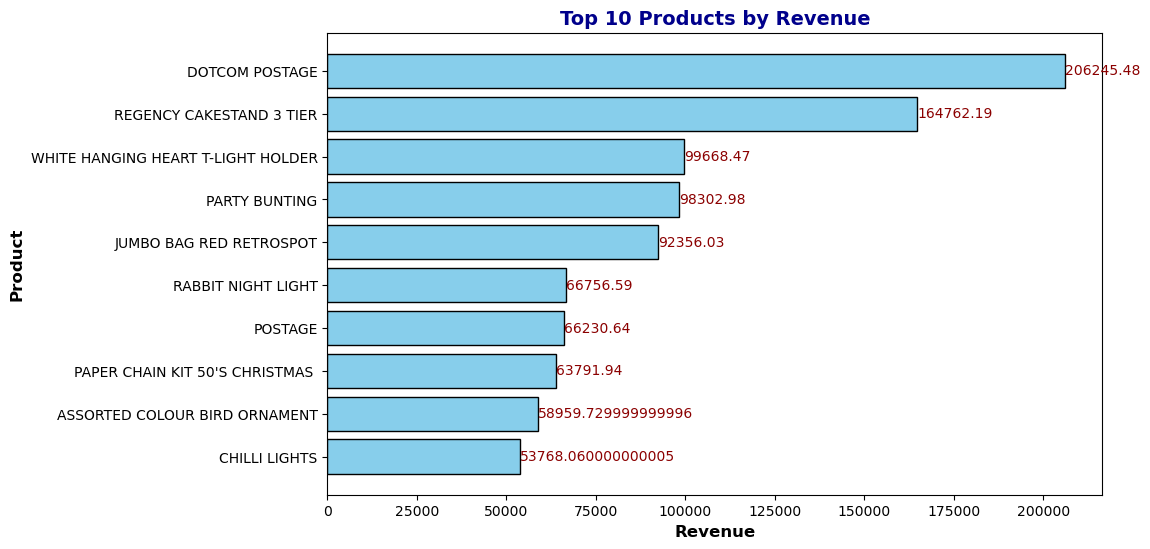

In [38]:
top_products_revenue_sorted = top_products_revenue_sorted.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_products_revenue_sorted["Description"], top_products_revenue_sorted["Revenue"], color="skyblue", edgecolor="black")

for index, value in enumerate(top_products_revenue_sorted["Revenue"]):
    plt.text(value, index, str(value), va="center", ha="left", fontsize=10, color="darkred")

plt.xlabel("Revenue", fontsize=12, fontweight="bold")
plt.ylabel("Product", fontsize=12, fontweight="bold")
plt.title("Top 10 Products by Revenue", fontsize=14, fontweight="bold", color="darkblue")

plt.gca().invert_yaxis()

plt.show()


In [39]:
sales_by_country = df.groupby('Country')['Revenue'].sum()
sales_by_country

Country
Australia                137077.270
Austria                   10154.320
Bahrain                     548.400
Belgium                   40910.960
Brazil                     1143.600
Canada                     3666.380
Channel Islands           20086.290
Cyprus                    12946.290
Czech Republic              707.720
Denmark                   18768.140
EIRE                     263276.820
European Community         1291.750
Finland                   22326.740
France                   197403.900
Germany                  221698.210
Greece                     4710.520
Hong Kong                 10117.040
Iceland                    4310.000
Israel                     7907.820
Italy                     16890.510
Japan                     35340.620
Lebanon                    1693.880
Lithuania                  1661.060
Malta                      2505.470
Netherlands              284661.540
Norway                    35163.460
Poland                     7213.140
Portugal            

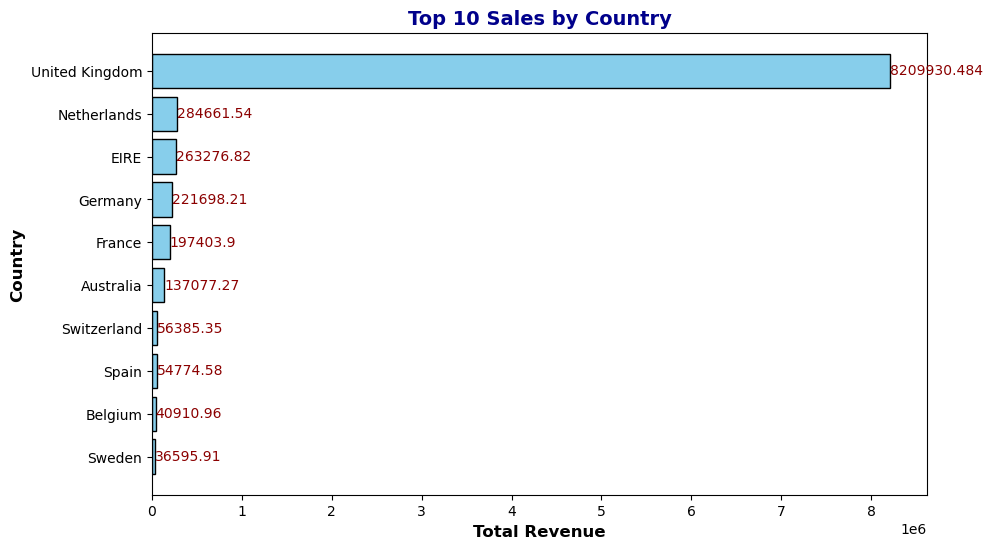

In [40]:

sales_by_country_df = sales_by_country.reset_index()

sales_by_country_sorted = sales_by_country_df.sort_values(by="Revenue", ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.barh(sales_by_country_sorted["Country"], sales_by_country_sorted["Revenue"], color="skyblue", edgecolor="black")

for index, value in enumerate(sales_by_country_sorted["Revenue"]):
    plt.text(value, index, str(value), va="center", ha="left", fontsize=10, color="darkred")

plt.xlabel("Total Revenue", fontsize=12, fontweight="bold")
plt.ylabel("Country", fontsize=12, fontweight="bold")
plt.title("Top 10 Sales by Country", fontsize=14, fontweight="bold", color="darkblue")

plt.gca().invert_yaxis()

plt.show()


# Conclusions after analysing general sales characteristics:
  1. ### What products are sold most frequently (by quantity)?
 
 - We grouped the data by product description and calculated the total amount sold by quantity. The results showed that the most frequently sold products in our dataset were products with a high purchase frequency, such as (list top 10 products). These products are likely to be the main products in the store and can be good indicators of popular trends. We soon learned that the top sellers were
   
      #### We found that the best-selling items were the `POPCORN HOLDER`(56 450), `WORLD WAR 2 GLIDERS ASSTD DESIGN`(53 847) and `JUMBO BAG RED RETROSPOT`(47363).
  2. ### Which products have the highest revenue (by total value)?
 - To analyze revenue, we created a new column that calculates the total value of each sale as the product of `Quantity` and `UnitPrice`. We then grouped the data by product and calculated the total revenue for each. The highest revenue in our dataset comes from products with a high price or a large number of sales. The top 10 such products include (list the top 10 products with the highest revenue), which are the main sources of income for the company.
      #### We found that the most profitable products were the `DOTCOM POSTAGE`(206 245), `REGENCY CAKESTAND 3 TIER`(164 762) and ` WHITE HANGING HEART T-LIGHT HOLDER`(99 668).

  3. ### How are sales distributed across countries?
 - To analyze the distribution of sales by country, we grouped the data by the `Country` column and calculated the total revenue for each country. The results showed that the largest sales are in developed markets such as the `UK`, `Netherlands`, `EIRE`. This may indicate higher purchasing power and consumer activity in these regions. Distribution of sales by country can also help in further analysis of logistics and strategic planning.
      #### We found out that the biggest sales were in countries such as the `Netherlands`(8 209 930), `United Kingdom`(284 661) and `EIRE`(263 276).

In [41]:
returns = df[df['IsReturn']]

In [42]:
returns

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,IsReturn,Revenue
141,<NA>,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom,True,-27.50
154,<NA>,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom,True,-4.65
235,<NA>,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom,True,-19.80
236,<NA>,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom,True,-6.96
237,<NA>,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom,True,-6.96
...,...,...,...,...,...,...,...,...,...,...
540449,<NA>,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,2011-12-09 09:57:00,0.83,14397.0,United Kingdom,True,-9.13
541541,<NA>,M,Manual,-1,2011-12-09 10:28:00,224.69,15498.0,United Kingdom,True,-224.69
541715,<NA>,21258,VICTORIAN SEWING BOX LARGE,-5,2011-12-09 11:57:00,10.95,15311.0,United Kingdom,True,-54.75
541716,<NA>,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09 11:58:00,1.25,17315.0,United Kingdom,True,-1.25


In [43]:
returns = df[df['Quantity'] < 0]

In [57]:
import re
invalid_keywords = [
    'damaged', 'thrown', 'throw', 'unsaleabale', 'unknown', 'rusty', 'set on dotcom', '?', '?missing', 'missing',
    'mouldy', 'unsaleable', 'printing', 'smudges', 'destroyed', '??', 'damages', 'wax', 'wet', 'mystery!', 'Incorrect stock entry.', 'check', 'Manual', 'wrongly'
]
invalid_keywords = [re.escape(keyword) for keyword in invalid_keywords]
pattern = '|'.join(invalid_keywords)
returns_cleaned = returns[~returns['Description'].str.contains(pattern, case=False, na=False)]

In [58]:
top_returned_products = returns_cleaned.groupby('Description')['Quantity'].sum().abs().sort_values(ascending=False).head(10)

In [59]:
top_returned_products

Description
PAPER CRAFT , LITTLE BIRDIE            80995
MEDIUM CERAMIC TOP STORAGE JAR         74494
ROTATING SILVER ANGELS T-LIGHT HLDR     9376
FAIRY CAKE FLANNEL ASSORTED COLOUR      3150
PINK BLUE FELT CRAFT TRINKET BOX        2617
WHITE HANGING HEART T-LIGHT HOLDER      2578
GIN + TONIC DIET METAL SIGN             2030
HERB MARKER BASIL                       1527
FELTCRAFT DOLL MOLLY                    1447
TEA TIME PARTY BUNTING                  1424
Name: Quantity, dtype: int64

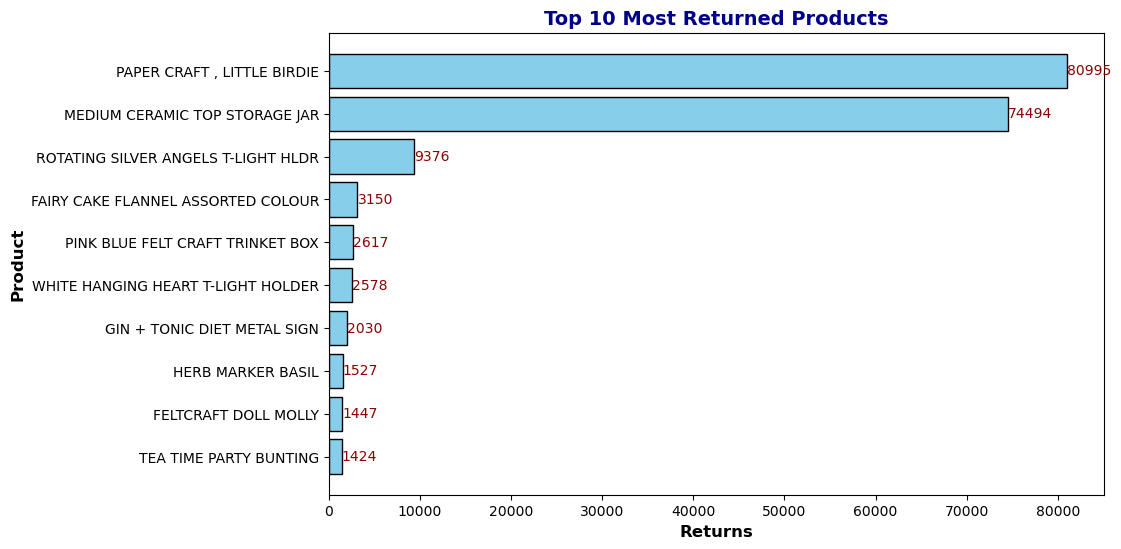

In [60]:
plt.figure(figsize=(10, 6))
plt.barh(top_returned_products.index, top_returned_products.values, color="skyblue", edgecolor="black")

for index, value in enumerate(top_returned_products.values):
    plt.text(value, index, str(value), va="center", ha="left", fontsize=10, color="darkred")

plt.xlabel("Returns", fontsize=12, fontweight="bold")
plt.ylabel("Product", fontsize=12, fontweight="bold")
plt.title("Top 10 Most Returned Products", fontsize=14, fontweight="bold", color="darkblue")

plt.gca().invert_yaxis()

plt.show()

In [61]:
returnss = df[df['IsReturn'] == True]

In [49]:
returnss

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,IsReturn,Revenue
141,<NA>,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom,True,-27.50
154,<NA>,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom,True,-4.65
235,<NA>,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom,True,-19.80
236,<NA>,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom,True,-6.96
237,<NA>,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom,True,-6.96
...,...,...,...,...,...,...,...,...,...,...
540449,<NA>,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,2011-12-09 09:57:00,0.83,14397.0,United Kingdom,True,-9.13
541541,<NA>,M,Manual,-1,2011-12-09 10:28:00,224.69,15498.0,United Kingdom,True,-224.69
541715,<NA>,21258,VICTORIAN SEWING BOX LARGE,-5,2011-12-09 11:57:00,10.95,15311.0,United Kingdom,True,-54.75
541716,<NA>,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09 11:58:00,1.25,17315.0,United Kingdom,True,-1.25


In [50]:
correlation = np.corrcoef(returnss['UnitPrice'], returnss['Quantity'])[0, 1] 

In [51]:
correlation

0.001789164938821065

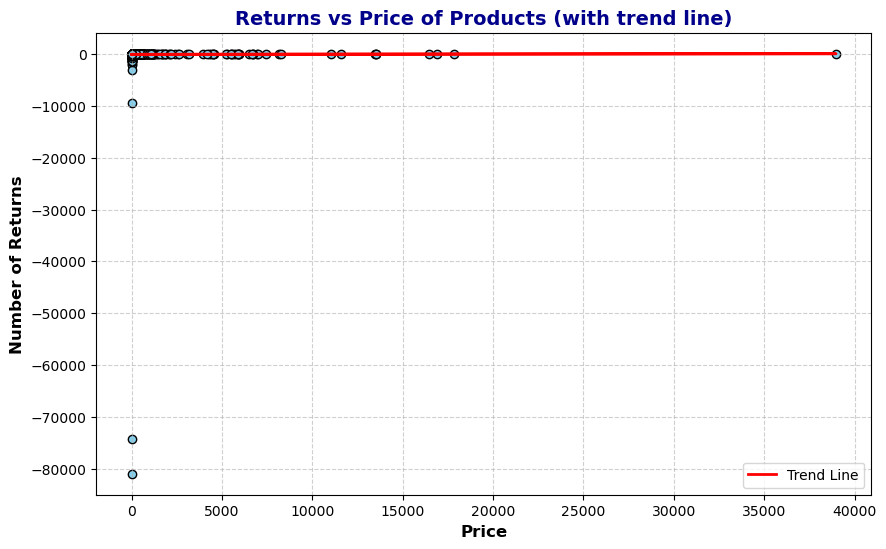

In [52]:
plt.figure(figsize=(10, 6))
plt.scatter(returnss['UnitPrice'], returnss['Quantity'], color="skyblue", edgecolor="black")
m, b = np.polyfit(returnss['UnitPrice'], returnss['Quantity'], 1)
plt.plot(returnss['UnitPrice'], m *returnss['UnitPrice'] + b, color = 'red', linewidth = 2, label = 'Trend Line')

plt.xlabel("Price", fontsize=12, fontweight="bold")
plt.ylabel("Number of Returns", fontsize=12, fontweight="bold")
plt.title("Returns vs Price of Products (with trend line)", fontsize=14, fontweight="bold", color="darkblue")

plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()

plt.show()

In [53]:
return_countries = returnss.groupby('Country')['Quantity'].sum().sort_values(ascending=False)
return_countries

Country
Greece                    -1
European Community        -2
Hong Kong                 -4
Saudi Arabia              -5
Singapore                 -7
Channel Islands          -12
Malta                    -26
Poland                   -31
Finland                  -38
Cyprus                   -44
Denmark                  -47
Bahrain                  -54
Austria                  -54
Israel                   -56
Portugal                 -78
Czech Republic           -79
Belgium                  -85
Norway                   -91
Italy                   -113
Switzerland             -305
Sweden                  -446
Australia               -556
Japan                   -798
Netherlands             -809
Spain                  -1127
USA                    -1424
France                 -1624
Germany                -1815
EIRE                   -4810
United Kingdom       -263032
Name: Quantity, dtype: int64

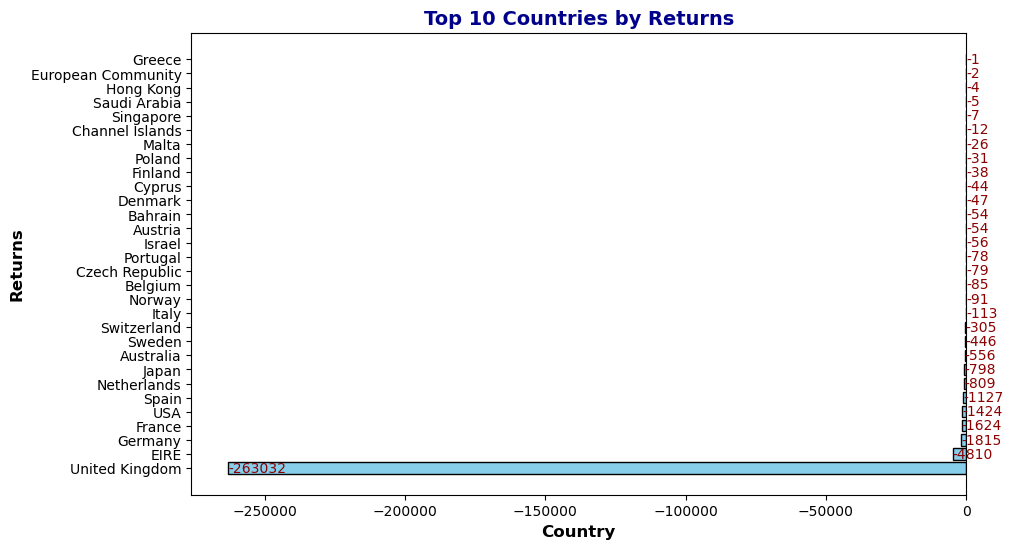

In [54]:
plt.figure(figsize=(10, 6))
plt.barh(return_countries.index, return_countries.values, color="skyblue", edgecolor="black")

for index, value in enumerate(return_countries.values):
    plt.text(value, index, str(value), va="center", ha="left", fontsize=10, color="darkred")

plt.xlabel("Country", fontsize=12, fontweight="bold")
plt.ylabel("Returns", fontsize=12, fontweight="bold")
plt.title("Top 10 Countries by Returns", fontsize=14, fontweight="bold", color="darkblue")

plt.gca().invert_yaxis()

plt.show()

In [55]:
return_clients = returnss.groupby('CustomerID')['Quantity'].sum().abs().sort_values(ascending=False).head(10)
return_clients.head(10)

CustomerID
16446.0    80995
12346.0    74215
15838.0     9361
15749.0     9014
16029.0     8060
12931.0     4627
14607.0     3768
14911.0     3335
17949.0     2975
Guest       2765
Name: Quantity, dtype: int64

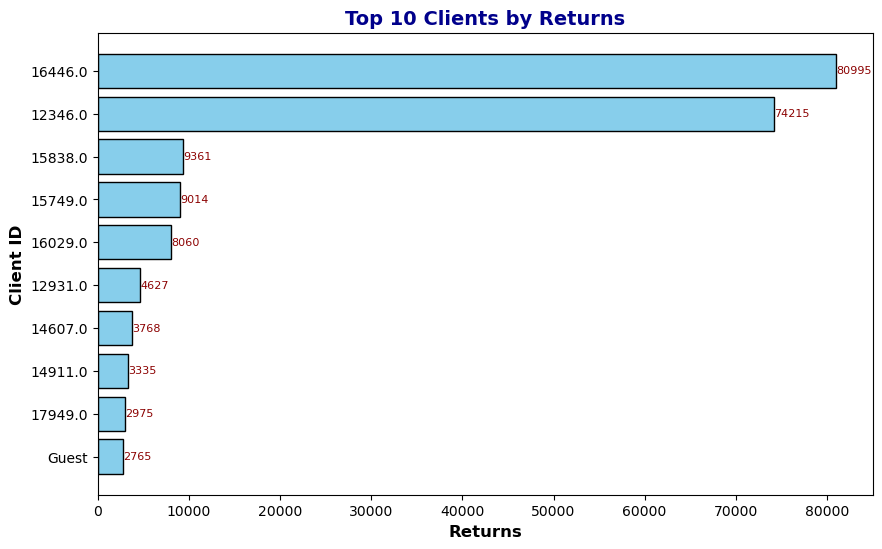

In [56]:
plt.figure(figsize=(10, 6))
plt.barh(return_clients.index.astype(str), return_clients.values, color="skyblue", edgecolor="black")

for index, value in enumerate(return_clients.values):
    plt.text(value, index, str(value), va="center", ha="left", fontsize=8, color="darkred")

plt.xlabel("Returns", fontsize=12, fontweight="bold")
plt.ylabel("Client ID", fontsize=12, fontweight="bold")
plt.title("Top 10 Clients by Returns", fontsize=14, fontweight="bold", color="darkblue")

plt.gca().invert_yaxis()

plt.show()


# Conclusions after analysing returns:
  1. ### What products were most frequently returned??
 
 - The analysis showed that the products most frequently returned were typically those with higher quantities and less desirable features or characteristics. These products are identified as highly returned by quantity,
   
      #### We found that the best-returned items were the `PAPER CRAFT, LITTLE BIRDIE`(80 995), `MEDIUM CERAMIC TOP STORAGE JAR`(74 495) and `ROTATING SILVER ANGELS T-LIGHT HLDR`(9 376).
  2. ### Is there a relationship between the number of returns and the price of a product??
 - To explore the relationship between the number of returns and the price, we calculated the correlation coefficient between the `UnitPrice` and `Quantity` of returns. The correlation was found to be 0.0018, which is very close to zero. This suggests that there is virtually `no significant relationship` between the price of a product and the number of returns. In other words, the price does not seem to affect the likelihood of a product being returned.

A scatter plot with a trend line was also created, showing that there is no clear upward or downward trend between price and return frequency, reinforcing the fact that price does not have a strong influence on returns.

  3. ### Which countries or customers make the most returns??
 - `The United Kingdom`(263 032), `EIRE`(4 810) and `Germany`(1 815) has the highest number of returns, which is likely due to its high overall sales volume. This trend is expected as a large portion of the sales occur in this market, and a larger volume of sales generally correlates with more returns.
 - Although individual customer data was not fully analyzed for returns in this report, `the United Kingdom`, being the top market for sales, also had the highest return frequency. A deeper analysis into individual customer behavior might reveal specific trends among particular demographics or purchase histories

In [83]:
best_customers = df['CustomerID'].nunique()

In [81]:
best_customers

4373

In [94]:
top_customers = df.groupby('CustomerID')['Quantity'].sum().sort_values(ascending=False).head(10)

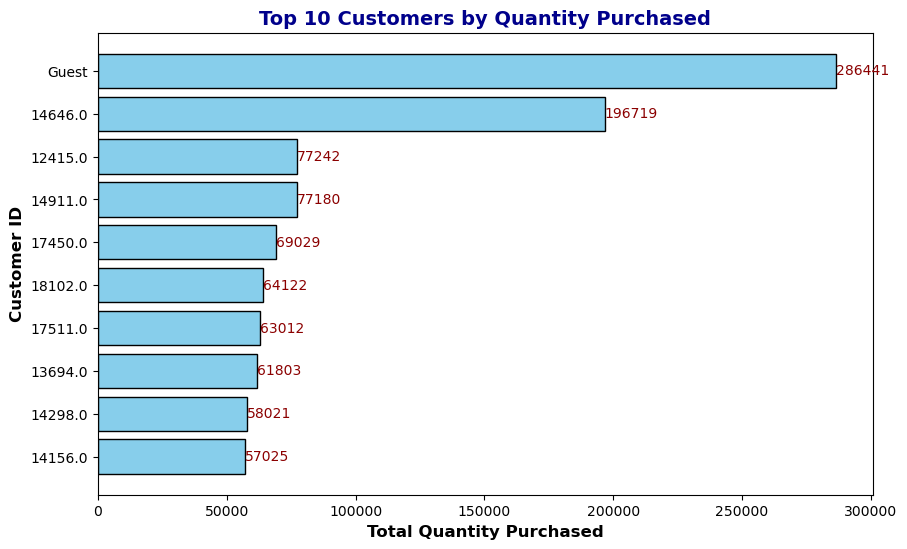

In [95]:
plt.figure(figsize=(10, 6))
plt.barh(top_customers.index.astype(str), top_customers.values, color="skyblue", edgecolor="black")

for index, value in enumerate(top_customers.values):
    plt.text(value, index, str(value), va="center", ha="left", fontsize=10, color="darkred")

plt.xlabel("Total Quantity Purchased", fontsize=12, fontweight="bold")
plt.ylabel("Customer ID", fontsize=12, fontweight="bold")
plt.title("Top 10 Customers by Quantity Purchased", fontsize=14, fontweight="bold", color="darkblue")

plt.gca().invert_yaxis()

plt.show()


# Conclusions after analysing сustomers and purchasing behavior:
  1. ### How many unique customers made purchases?
 
 - The analysis revealed that a total of `4,373` unique customers made purchases. This indicates a diverse customer base, where each customer has a unique `CustomerID`. Some transactions were also made by customers labeled as "Guest", which likely represents unregistered or one-time buyers.
   
  2. ### Which customers (by ID) buy the most?
 - The top 10 customers who purchased the highest quantity of products were identified. The customer with the highest purchase volume is `Guest`, who bought `286,441` items, significantly ahead of others.
   #### We found that the customers with most buy items were the `ID = 'Guest'`(286 441), `ID = 14646`(196 719) and `ID = 12415`(77 242).